LLM captioning failed so we r trying microsoft git for the true video captioning 

Loading microsoft/git-base-vatex to cuda...
⚡ Applying Weight Fixes...


C:\Users\rajam\AppData\Local\Temp\ipykernel_21296\3973066469.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location="cpu"

✅ Model Loaded & Patched Successfully!

🎥 Watching: v_Basketball_g22_c03.avi


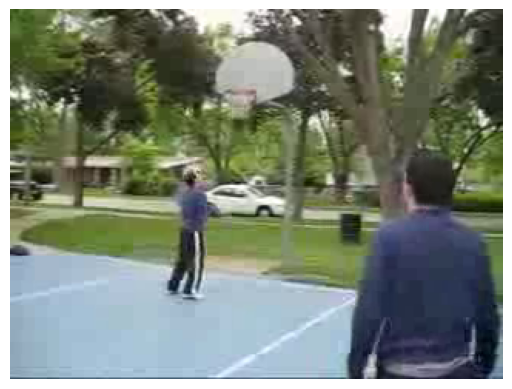

🤖 True Visual Caption: 'two boys are playing basketball on a basketball court outside.'


In [2]:
# FILE: 06_True_Captioning.ipynb

import torch
from transformers import AutoProcessor, AutoModelForCausalLM, AutoConfig
from huggingface_hub import hf_hub_download
import cv2
import numpy as np
from PIL import Image
import os
import random
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
MODEL_NAME = "microsoft/git-base-vatex" 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading {MODEL_NAME} to {DEVICE}...")

# 1. DOWNLOAD & PATCH THE WEIGHTS (The Surgery)
print("⚡ Applying Weight Fixes...")

# Download weights manually
checkpoint_path = hf_hub_download(repo_id=MODEL_NAME, filename="pytorch_model.bin")
state_dict = torch.load(checkpoint_path, map_location="cpu")

new_state_dict = {}
for k, v in state_dict.items():
    # FIX 1: Rename 'temperal' -> 'temporal'
    if "temperal" in k:
        new_k = k.replace("temperal", "temporal")
        new_state_dict[new_k] = v
    else:
        new_state_dict[k] = v

# FIX 2: Remove unexpected 'position_ids' (The new error)
# These are helper buffers that the model recreates automatically
keys_to_remove = [
    "git.embeddings.position_ids",
    "git.image_encoder.vision_model.embeddings.position_ids"
]
for key in keys_to_remove:
    if key in new_state_dict:
        del new_state_dict[key]

# 2. INITIALIZE MODEL
config = AutoConfig.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_config(config)
model.load_state_dict(new_state_dict) # Now it should be clean
model = model.to(DEVICE)
processor = AutoProcessor.from_pretrained(MODEL_NAME)

print("✅ Model Loaded & Patched Successfully!")

# 3. FRAME EXTRACTION
def extract_frames(video_path, num_frames=6):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []
    if total_frames > 0:
        indices = np.linspace(0, total_frames - 1, num_frames).astype(int)
        for i in range(total_frames):
            ret, frame = cap.read()
            if not ret: break
            if i in indices:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(Image.fromarray(frame))
    cap.release()
    return frames

# 4. GENERATE CAPTION
def generate_true_caption(video_path):
    frames = extract_frames(video_path)
    if not frames: return "Error reading video."

    inputs = processor(images=[frames], return_tensors="pt")
    pixel_values = inputs.pixel_values.to(DEVICE)
    
    generated_ids = model.generate(
        pixel_values=pixel_values, 
        max_length=50,
        num_beams=4,
    )
    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return caption

# --- TEST IT ---
DATASET_ROOT = "data/UCF50"
test_class = "Basketball" # Try 'Diving' or 'HorseRiding'
video_folder = os.path.join(DATASET_ROOT, test_class)

if os.path.exists(video_folder):
    video_name = random.choice(os.listdir(video_folder))
    video_path = os.path.join(video_folder, video_name)
    
    print(f"\n🎥 Watching: {video_name}")
    
    # Show middle frame
    frames = extract_frames(video_path)
    if frames:
        plt.imshow(frames[3])
        plt.axis('off')
        plt.show()

    # Get Caption
    true_caption = generate_true_caption(video_path)
    print(f"🤖 True Visual Caption: '{true_caption}'")
else:
    print("Folder not found.")